In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.decomposition import PCA

In [16]:
agilent = pd.read_csv('Datasets/AgilentG4502A_07_3', sep='\t', index_col=0)
agilent = agilent.T

clinical = pd.read_csv('Datasets/TCGA.BRCA.sampleMap_BRCA_clinicalMatrix', sep='\t')
clinical['label'] = clinical['sample_type'].apply(lambda x: 1 if 'Tumor' in str(x) else 0)

agilent.index.name = 'sampleID'
merged = agilent.merge(clinical[['sampleID', 'label']], left_index=True, right_on='sampleID')

print('Merged shape:', merged.shape)
X = merged.drop(['sampleID', 'label'], axis=1).values
y = merged['label'].values
print('Label distribution:', dict(zip(*np.unique(y, return_counts=True))))

Merged shape: (597, 17816)
Label distribution: {np.int64(0): np.int64(66), np.int64(1): np.int64(531)}


In [17]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train_raw.shape}\nTest: {X_test_raw.shape}')

Train: (477, 17814)
Test: (120, 17814)


In [18]:
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train_raw)
X_test_imp  = imputer.transform(X_test_raw)

In [19]:
selector = SelectKBest(f_classif, k=100)
X_train_sel = selector.fit_transform(X_train_imp, y_train)
X_test_sel  = selector.transform(X_test_imp)

print(f'Train selected: {X_train_sel.shape}\nTest selected: {X_test_sel.shape}')

Train selected: (477, 100)
Test selected: (120, 100)


In [20]:
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='rbf', random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train_sel, y_train)
    preds = model.predict(X_test_sel)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(f'\n── {name} ──')
    print(classification_report(y_test, preds, target_names=['Normal', 'Tumor']))

print('\nFinal accuracies:', results)


── Random Forest ──
              precision    recall  f1-score   support

      Normal       1.00      0.85      0.92        13
       Tumor       0.98      1.00      0.99       107

    accuracy                           0.98       120
   macro avg       0.99      0.92      0.95       120
weighted avg       0.98      0.98      0.98       120


── SVM ──
              precision    recall  f1-score   support

      Normal       1.00      0.85      0.92        13
       Tumor       0.98      1.00      0.99       107

    accuracy                           0.98       120
   macro avg       0.99      0.92      0.95       120
weighted avg       0.98      0.98      0.98       120


── Logistic Regression ──
              precision    recall  f1-score   support

      Normal       1.00      0.92      0.96        13
       Tumor       0.99      1.00      1.00       107

    accuracy                           0.99       120
   macro avg       1.00      0.96      0.98       120
weighted avg   

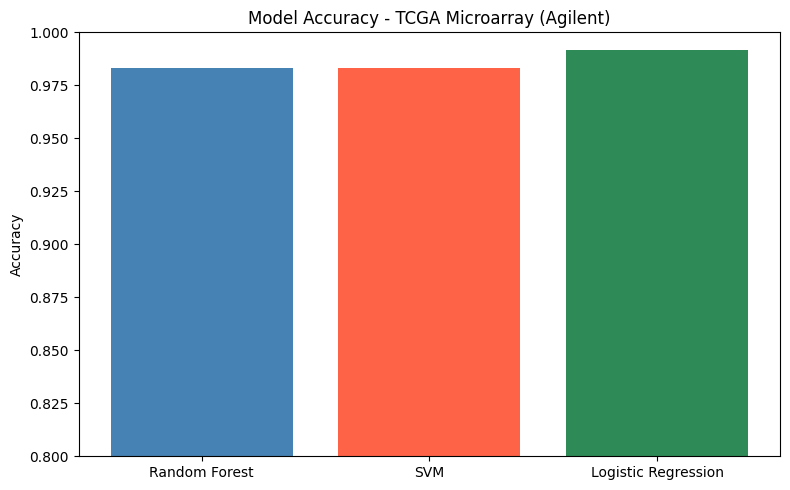

In [24]:
plt.figure(figsize=(8, 5))
plt.bar(results.keys(), results.values(), color=['steelblue', 'tomato', 'seagreen'])
plt.title('Model Accuracy - TCGA Microarray (Agilent)')
plt.ylabel('Accuracy')
plt.ylim(0.8, 1.0)
plt.tight_layout()
plt.savefig('microarray_accuracy.png', dpi=150)
plt.show()

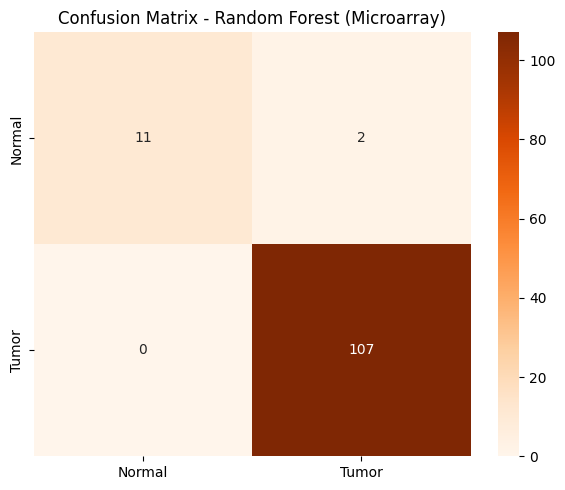

In [25]:
rf_preds = models['Random Forest'].predict(X_test_sel)
cm = confusion_matrix(y_test, rf_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Normal', 'Tumor'],
            yticklabels=['Normal', 'Tumor'])
plt.title('Confusion Matrix - Random Forest (Microarray)')
plt.tight_layout()
plt.savefig('microarray_confusion.png', dpi=150)
plt.show()

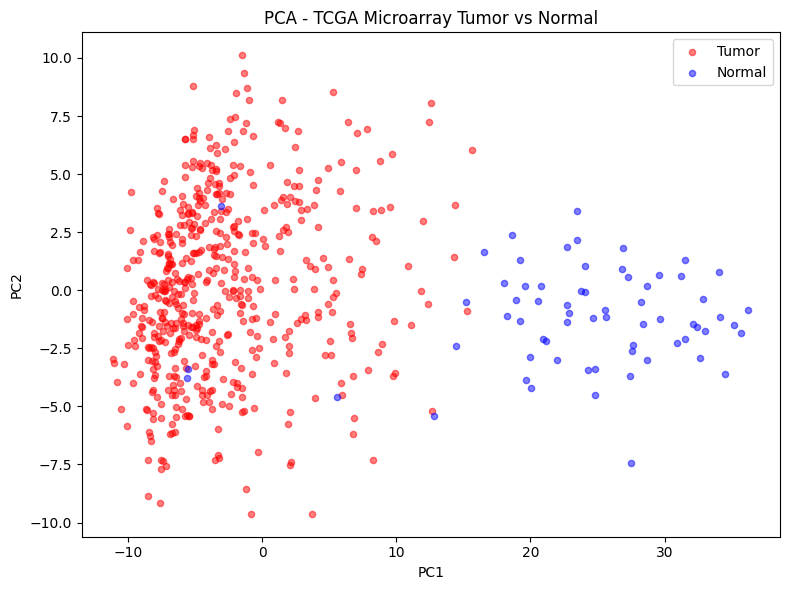

Accuracies: {'Random Forest': 0.9833333333333333, 'SVM': 0.9833333333333333, 'Logistic Regression': 0.9916666666666667}


In [26]:
X_all_imp = imputer.transform(X)
X_all_sel = selector.transform(X_all_imp)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_all_sel)

plt.figure(figsize=(8, 6))
for label, color, name in [(1, 'red', 'Tumor'), (0, 'blue', 'Normal')]:
    idx = y == label
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], c=color, label=name, alpha=0.5, s=20)
plt.title('PCA - TCGA Microarray Tumor vs Normal')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.tight_layout()
plt.savefig('microarray_pca.png', dpi=150)
plt.show()

print('Accuracies:', results)